In [1]:
import numpy as np
import hydra
from omegaconf import OmegaConf
from utils import build_datasets, build_model
from dal_toolbox.utils import seed_everything

with hydra.initialize(config_path="configs"):
    args = hydra.compose(config_name="active_learning")
    print(OmegaConf.to_yaml(args))

seed_everything(42)
train_ds, _, _ = build_datasets(args)
model = build_model(args, 384, 10)

/tmp/ipykernel_3810764/1306951681.py:7: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with hydra.initialize(config_path="configs"):
/home/dhuseljic/miniconda3/envs/dal/lib/python3.12/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'active_learning': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
Seed set to 42


dataset:
  name: cifar10
  path: /home/datasets
  cache_features: true
  num_acq: 20
  acq_size: 10
  subset_size: 1000
  num_init: null
random_seed: 1
experiment_name: al
mlflow_uri: sqlite:///active_learning.db
num_workers: 0
al:
  strategy: refine
  device: cpu
  refine:
    strategies:
    - margin
    - typiclust
    progressive_depth: 5
    num_batches: 100
    alpha: 0.4
    filter_acq_size: null
    init_subset_size: 5000
    max_pool_size: 10000
    select_strategy: random
  aal:
    loss: zero_one
    eval_gt: true
    num_mc_labels: 10
    num_retraining_epochs: 50
    look_ahead: mc_labels
    perf_estimation: unlabeled_pool
model:
  name: linear
  num_epochs: 200
  train_batch_size: 64
  predict_batch_size: 128
  mean_field_factor: 0.4
  mc_samples: 10000
  backbone: dinov2
optimizer:
  name: SGD
  lr: 0.01
  weight_decay: 0.0005
  momentum: 0.9
  nesterov: true
  lr_backbone: 1.0e-05
  finetune_backbone: false
output_dir: ./output/



Using cache found in /home/dhuseljic/.cache/torch/hub/facebookresearch_dinov2_main
/home/dhuseljic/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/dhuseljic/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/dhuseljic/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Loading cached features from /home/datasets/531f36791fe15677da7668885fe2ba15.pth
Loading cached features from /home/datasets/753be9f946f56dfd90e4590a35be6ff2.pth


In [2]:
import torch
from sklearn.manifold import TSNE
from torch.utils.data import TensorDataset
from dal_toolbox.active_learning import ActiveLearningDataModule

num_samples = 5000
X_feat = np.array([train_ds[i][0].numpy() for i in range(num_samples)])
y_feat = np.array([train_ds[i][1].numpy() for i in range(num_samples)])
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_feat)

train_ds = TensorDataset(torch.from_numpy(X_feat).float(), torch.from_numpy(y_feat).long())
al_datamodule = ActiveLearningDataModule(
    train_dataset=train_ds,
    train_batch_size=args.model.train_batch_size,
    predict_batch_size=args.model.predict_batch_size,
)
args.dataset.num_init = args.dataset.acq_size if args.dataset.num_init is None else args.dataset.num_init
al_datamodule.random_init(n_samples=50) 

/home/dhuseljic/dal-toolbox2.0/dal_toolbox/active_learning/data.py:69: UserWarning: Using train_dataset for queries. Ensure that there are no augmentations used.
  rank_zero_warn('Using train_dataset for queries. Ensure that there are no augmentations used.')


In [3]:
from lightning import Trainer

lightning_trainer_config = dict(
    max_epochs=args.model.num_epochs,
    barebones=True,
    # callbacks=[MetricLogger()],
)
model.reset_states()
trainer = Trainer(**lightning_trainer_config)
trainer.fit(model, train_dataloaders=al_datamodule.train_dataloader())

with torch.no_grad():
    logits = model(train_ds.tensors[0])
    print(torch.mean((logits.argmax(-1) == train_ds.tensors[1]).float()))

You are running in `Trainer(barebones=True)` mode. All features that may impact raw speed have been disabled to facilitate analyzing the Trainer overhead. Specifically, the following features are deactivated:
 - Checkpointing: `Trainer(enable_checkpointing=True)`
 - Progress bar: `Trainer(enable_progress_bar=True)`
 - Model summary: `Trainer(enable_model_summary=True)`
 - Logging: `Trainer(logger=True)`, `Trainer(log_every_n_steps>0)`, `LightningModule.log(...)`, `LightningModule.log_dict(...)`
 - Sanity checking: `Trainer(num_sanity_val_steps>0)`
 - Development run: `Trainer(fast_dev_run=True)`
 - Anomaly detection: `Trainer(detect_anomaly=True)`
 - Profiling: `Trainer(profiler=...)`
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
`Trainer(barebones=True)` started running. The progress bar is disabled so you might want to manually print the progress in your model.
/home/dhuseljic/miniconda3/envs/dal/lib/python3.12/site-packages/lightning/pytorch/trainer

tensor(0.8720)


In [17]:
from strategies import Refine
al_strategy = Refine(al_strategies=['margin', 'typiclust'], init_subset_size=1000)
query_indices = al_strategy.query(model=model, al_datamodule=al_datamodule, acq_size=10)

Output()

Output()

Output()

Output()

Output()

You are running in `Trainer(barebones=True)` mode. All features that may impact raw speed have been disabled to facilitate analyzing the Trainer overhead. Specifically, the following features are deactivated:
 - Checkpointing: `Trainer(enable_checkpointing=True)`
 - Progress bar: `Trainer(enable_progress_bar=True)`
 - Model summary: `Trainer(enable_model_summary=True)`
 - Logging: `Trainer(logger=True)`, `Trainer(log_every_n_steps>0)`, `LightningModule.log(...)`, `LightningModule.log_dict(...)`
 - Sanity checking: `Trainer(num_sanity_val_steps>0)`
 - Development run: `Trainer(fast_dev_run=True)`
 - Anomaly detection: `Trainer(detect_anomaly=True)`
 - Profiling: `Trainer(profiler=...)`
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
`Trainer(barebones=True)` started running. The progress bar is disabled so you might want to manually print the progress in your model.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Pool Sizes: {1: 415, 2: 225, 3: 184, 4: 164, 5: 151}


`Trainer.fit` stopped: `max_epochs=200` reached.


/tmp/ipykernel_3810764/2342374017.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_tsne[:,0], X_tsne[:,1], c='gray', cmap='tab10', s=1)
/tmp/ipykernel_3810764/2342374017.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_tsne[filtered_indices ,0], X_tsne[filtered_indices ,1], c='k', marker='x', lw=2, cmap='tab10', s=50)


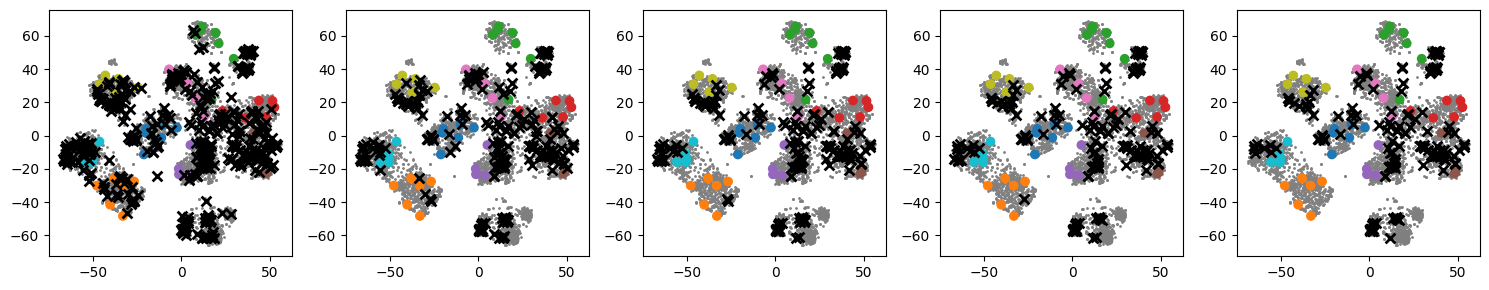

In [37]:
import pylab as plt
num_rows, num_cols = 1, len(al_strategy.pool_indices)
labeled_indices = al_datamodule.labeled_indices
fig, ax = plt.subplots(1, num_cols, figsize=(num_cols*3, num_rows*3))
for r, filtered_indices in al_strategy.pool_indices.items():
    plt.sca(ax[r])
    plt.scatter(X_tsne[:,0], X_tsne[:,1], c='gray', cmap='tab10', s=1)
    plt.scatter(X_tsne[labeled_indices,0], X_tsne[labeled_indices,1], c=y_feat[labeled_indices], cmap='tab10')
    plt.scatter(X_tsne[filtered_indices ,0], X_tsne[filtered_indices ,1], c='k', marker='x', lw=2, cmap='tab10', s=50)
plt.tight_layout()

/tmp/ipykernel_3810764/854542893.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_tsne[:,0], X_tsne[:,1], c='gray', cmap='tab10', s=1)
/tmp/ipykernel_3810764/854542893.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_tsne[filtered_indices ,0], X_tsne[filtered_indices ,1], c='k', marker='x', lw=2, cmap='tab10', s=50)
/tmp/ipykernel_3810764/854542893.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_tsne[:,0], X_tsne[:,1], c='gray', cmap='tab10', s=1)
/tmp/ipykernel_3810764/854542893.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_tsne[filtered_indices ,0], X_tsne[filtered_indices ,1], c='k', marker='x', lw=2, cmap='tab10', s=50)
/tmp/ipykernel_3810764/854542893.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cm

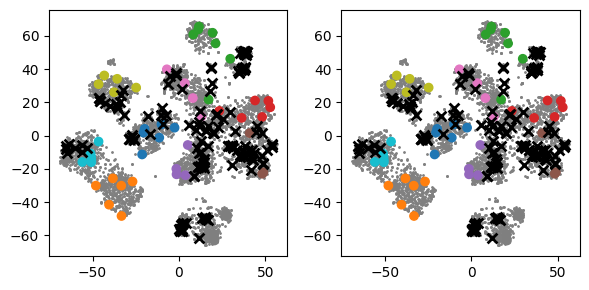

In [42]:
import pylab as plt
num_rows, num_cols = 1, 2
labeled_indices = al_datamodule.labeled_indices
fig, ax = plt.subplots(1, num_cols, figsize=(num_cols*3, num_rows*3))
filtered_indices = al_strategy.pool_indices[4]
plt.sca(ax[0])
plt.scatter(X_tsne[:,0], X_tsne[:,1], c='gray', cmap='tab10', s=1)
plt.scatter(X_tsne[labeled_indices,0], X_tsne[labeled_indices,1], c=y_feat[labeled_indices], cmap='tab10')
plt.scatter(X_tsne[filtered_indices ,0], X_tsne[filtered_indices ,1], c='k', marker='x', lw=2, cmap='tab10', s=50)

plt.sca(ax[1])
plt.scatter(X_tsne[:,0], X_tsne[:,1], c='gray', cmap='tab10', s=1)
plt.scatter(X_tsne[labeled_indices,0], X_tsne[labeled_indices,1], c=y_feat[labeled_indices], cmap='tab10')
plt.scatter(X_tsne[filtered_indices ,0], X_tsne[filtered_indices ,1], c='k', marker='x', lw=2, cmap='tab10', s=50)
plt.scatter(X_tsne[query_indices,0], X_tsne[query_indices,1], c='k', marker='x', lw=2, cmap='tab10', s=50)

plt.tight_layout()

/tmp/ipykernel_3810764/153422305.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c='gray', cmap='tab10', s=5, alpha=0.2)
/tmp/ipykernel_3810764/153422305.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c='gray', cmap='tab10', s=5, alpha=0.2, label='Unlabeled Pool')


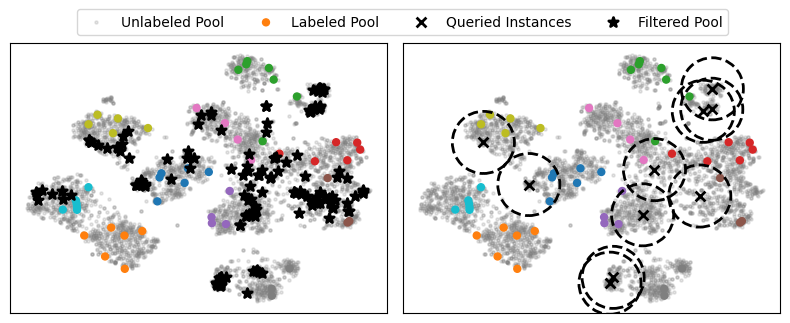

In [77]:
import pylab as plt
from copy import deepcopy
num_rows, num_cols = 1, 2
labeled_indices = al_datamodule.labeled_indices
filtered_indices = al_strategy.pool_indices[4]

fig, ax = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows *3))
plt.sca(ax[0])
# ax[0].set_title('Active Learning: Candidate Pool')

ax[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c='gray', cmap='tab10', s=5, alpha=0.2)
ax[0].scatter(X_tsne[labeled_indices, 0], X_tsne[labeled_indices, 1], c=y_feat[labeled_indices], cmap='tab10', s=25)
ax[0].scatter(X_tsne[filtered_indices, 0], X_tsne[filtered_indices, 1], c='k', marker='*', lw=2, s=50, label='Filtered Pool')

# ax[0].set_xlabel('t-SNE Component 1')
# ax[0].set_ylabel('t-SNE Component 2')
ax[0].set_xticks([])
ax[0].set_yticks([])

plt.sca(ax[1])
ax[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c='gray', cmap='tab10', s=5, alpha=0.2, label='Unlabeled Pool')
ax[1].scatter(X_tsne[labeled_indices, 0], X_tsne[labeled_indices, 1], c=y_feat[labeled_indices], label='Labeled Pool', cmap='tab10', s=25)
ax[1].scatter(X_tsne[query_indices, 0], X_tsne[query_indices, 1], c='k', marker='x', lw=2, s=50, label='Queried Instances')

ax[1].scatter(
    X_tsne[query_indices, 0],
    X_tsne[query_indices, 1],
    facecolors='none',   # Make the circle hollow
    edgecolors='k',    # Use a bright color to stand out
    linestyle='--',      # Use the requested dashed line
    lw=2,                # Line width
    s=2000,               # Make it larger to be visible
)

ax[1].scatter(
    [], [],              # Empty data, won't be plotted
    facecolors='none',   
    edgecolors='k',    
    linestyle='--',       
    lw=2,                
    s=150,               # This is the small size for the LEGEND
)
ax[1].scatter([], [], c='k', marker='*', lw=2, s=50, label='Filtered Pool')

# ax[1].set_xlabel('t-SNE Component 1')
ax[1].set_xticks([])
ax[1].set_yticks([])
plt.tight_layout()
ax[1].legend(ncols=5, loc='upper center', bbox_to_anchor=(0, 1.15))

import os
from pathlib import Path
plot_dir = Path('/home/dhuseljic/paper_plots/adaptive_al/')
os.makedirs(plot_dir, exist_ok=True)
plt.savefig(plot_dir / 'cifar10_tsne_ga.pdf', bbox_inches='tight')